In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
sys.path.insert(0, "/home/nboley/src/fragmentomics_tools/projects/")

In [15]:
import pandas

from fragments_h5 import FragmentsH5

from fragmentomics_tools.dataframe import Region, SampleDataFrame, RegionDataFrame, SampleAndRegionDataFrame
from fragmentomics_tools.bias_correction.data import build_counts
from fragmentomics_tools.plot.tracks import Tracks, VectorTrack

# Parallel Apply Code

In [ ]:
import pandas
import multiprocessing
import tqdm
import pickle

def _apply_fn(df, fn, counter, send_conn, send_conn_lock):
    rv = []
    while True:
        with counter.get_lock():
            idx = counter.value
            counter.value += 1
        if idx >= df.shape[0]:
            return

        try:
            res = fn(df.iloc[idx])
        except Exception as inst:
            msg = pickle.dumps(inst)
        else:
            msg = pickle.dumps((idx, res))
        with send_conn_lock:
            send_conn.send_bytes(msg)


def parallel_apply(df, fn, n_workers=None, verbose=True):
    # do this in a fork context so that we don't need to serialize the data into the new process
    ctx = multiprocessing.get_context('fork')
    # if the number of workers isn't set then use all available cpus
    if n_workers is None:
        n_workers = multiprocessing.cpu_count()

    # set a shared counter to track the row index to process
    counter = ctx.Value('i', 0)
    recv_conn, send_conn = ctx.Pipe(duplex=False)
    pipe_lock = multiprocessing.Lock()
    ps = [ctx.Process(target=_apply_fn, args=(df, fn, counter, send_conn, pipe_lock)) for _ in range(n_workers)]
    for p in ps: p.start()

    # clear any cache -- works around a jupyter display bug
    tqdm.tqdm._instances.clear()
    if verbose:
        pbar = tqdm.tqdm("parallel apply", total=df.shape[0])

    def _cleanup():
        # close the pipe
        send_conn.close()
        recv_conn.close()
    
        # join all of the worker processes
        for p in ps: p.join()

        if verbose:
            pbar.close()

    # store the returned row indices and records
    # we track the indices so that we can re-sort into the original order and then 
    # join with the input dataframe index
    indices = []
    records = []
    # keep processing new data until the returned records equals the inputs
    while len(indices) < df.shape[0]:
        if recv_conn.poll(0.1):
            # deal with intermitent "UnpicklingError: invalid load key, '\x00'." 
            try:
                res = pickle.loads(recv_conn.recv_bytes())
            except UnpicklingError:
                print("error", len(indices), df.shape)
                break
            # if a worker raised an exception kill any active process, cleanup, and then re-raise the exception
            if isinstance(res, Exception):
                for p in ps: p.kill()
                _cleanup()
                raise res

            i, rec = res
            indices.append(i)
            records.append(rec)
            if verbose:
                pbar.update(1)

    _cleanup()

    # concatanate all records into a dataframe
    rv = pandas.DataFrame(records)
    # add the numeric indices and sort to the original order
    rv.index = indices
    rv = rv.sort_index()
    # re-attach the original index
    rv.index = df.index


    return rv


# Samples

In [16]:
## Download the fragment h5
# aws --profile karius s3 cp s3://analytics.kariusdx.com/nathan_boley/ibd/IBD.RD-50561-Lib1_NC-13909.fragments.h5 /tmp/

In [17]:
sdf = SampleDataFrame(dict(sample_id=["RD-50561"], frag_h5=[FragmentsH5("/tmp/IBD.RD-50561-Lib1_NC-13909.fragments.h5")]))
sdf

,sample_id,frag_h5
0,RD-50561,<fragments_h5.fragments_h5.FragmentsH5 object ...


# TSS Sites

In [18]:
## Download the TSS bed
# aws --profile karius s3 cp s3://analytics.kariusdx.com/nathan_boley/ibd/tss_with_blood_expression.tsv /tmp/

In [19]:
tss_s = RegionDataFrame(pandas.read_table("/tmp/tss_with_blood_expression.tsv", index_col=0), ref='hg38')
tss_s

,gene_name,gene_id,contig,strand,start,stop,expression
0,A1BG,ENSG00000121410,chr19,-,58352468,58354516,62.542394
1,A1CF,ENSG00000148584,chr10,-,50858961,50861009,0.000000
2,A2M,ENSG00000175899,chr12,-,9114895,9116943,0.077835
3,A2ML1,ENSG00000166535,chr12,+,8821597,8823645,0.197852
4,A4GALT,ENSG00000128274,chr22,-,42694607,42696655,2.158199
...,...,...,...,...,...,...,...
17348,ZXDC,ENSG00000070476,chr3,-,126474867,126476915,19.699126
17349,ZYG11A,ENSG00000203995,chr1,+,52841487,52843535,0.000000
17350,ZYG11B,ENSG00000162378,chr1,+,52725429,52727477,28.688477
17351,ZYX,ENSG00000159840,chr7,+,143380321,143382369,118.715634


# TSS Analysis

In [8]:
srdf = SampleAndRegionDataFrame.init_from_rdf_and_sdf(tss_s.query("expression > 20 and strand == '+'"), sdf).attach_fragment_arrays(num_cores=24)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3442/3442 [00:03<00:00, 1116.17it/s]


In [10]:
import scipy
from fragmentomics_tools.bias_correction.data import build_counts
count_columns = [x for x in srdf.columns if x.startswith("pred_dist.")]
# tmp_obs = srdf.query("expression > 20").head(100).df.progress_apply(lambda x: build_counts(x).apply(scipy.sparse.coo_array), axis=1)

In [11]:
srdf.query("expression > 20").shape

(3442, 10)

In [12]:
%%time
res = parallel_apply(srdf.query("expression > 20"), lambda rec: build_counts(rec, return_sparse=True), n_workers=16)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3442/3442 [00:01<00:00, 1724.08it/s]


CPU times: user 1.46 s, sys: 537 ms, total: 2 s
Wall time: 2.53 s


In [15]:
cov = res.sum().progress_apply(lambda x: x.todense().ravel())

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 12/12 [00:00<00:00, 16394.67it/s]


(<Figure size 2500x2400 with 12 Axes>,
 [<Axes: title={'center': 'strand_+__fl_40_65__coverage_first'}>,
  <Axes: title={'center': 'strand_+__fl_40_65__coverage_last'}>,
  <Axes: title={'center': 'strand_+__fl_40_65__coverage_midpoint'}>,
  <Axes: title={'center': 'strand_+__fl_120_175__coverage_first'}>,
  <Axes: title={'center': 'strand_+__fl_120_175__coverage_last'}>,
  <Axes: title={'center': 'strand_+__fl_120_175__coverage_midpoint'}>,
  <Axes: title={'center': 'strand_-__fl_40_65__coverage_first'}>,
  <Axes: title={'center': 'strand_-__fl_40_65__coverage_last'}>,
  <Axes: title={'center': 'strand_-__fl_40_65__coverage_midpoint'}>,
  <Axes: title={'center': 'strand_-__fl_120_175__coverage_first'}>,
  <Axes: title={'center': 'strand_-__fl_120_175__coverage_last'}>,
  <Axes: title={'center': 'strand_-__fl_120_175__coverage_midpoint'}, xlabel='NA'>])

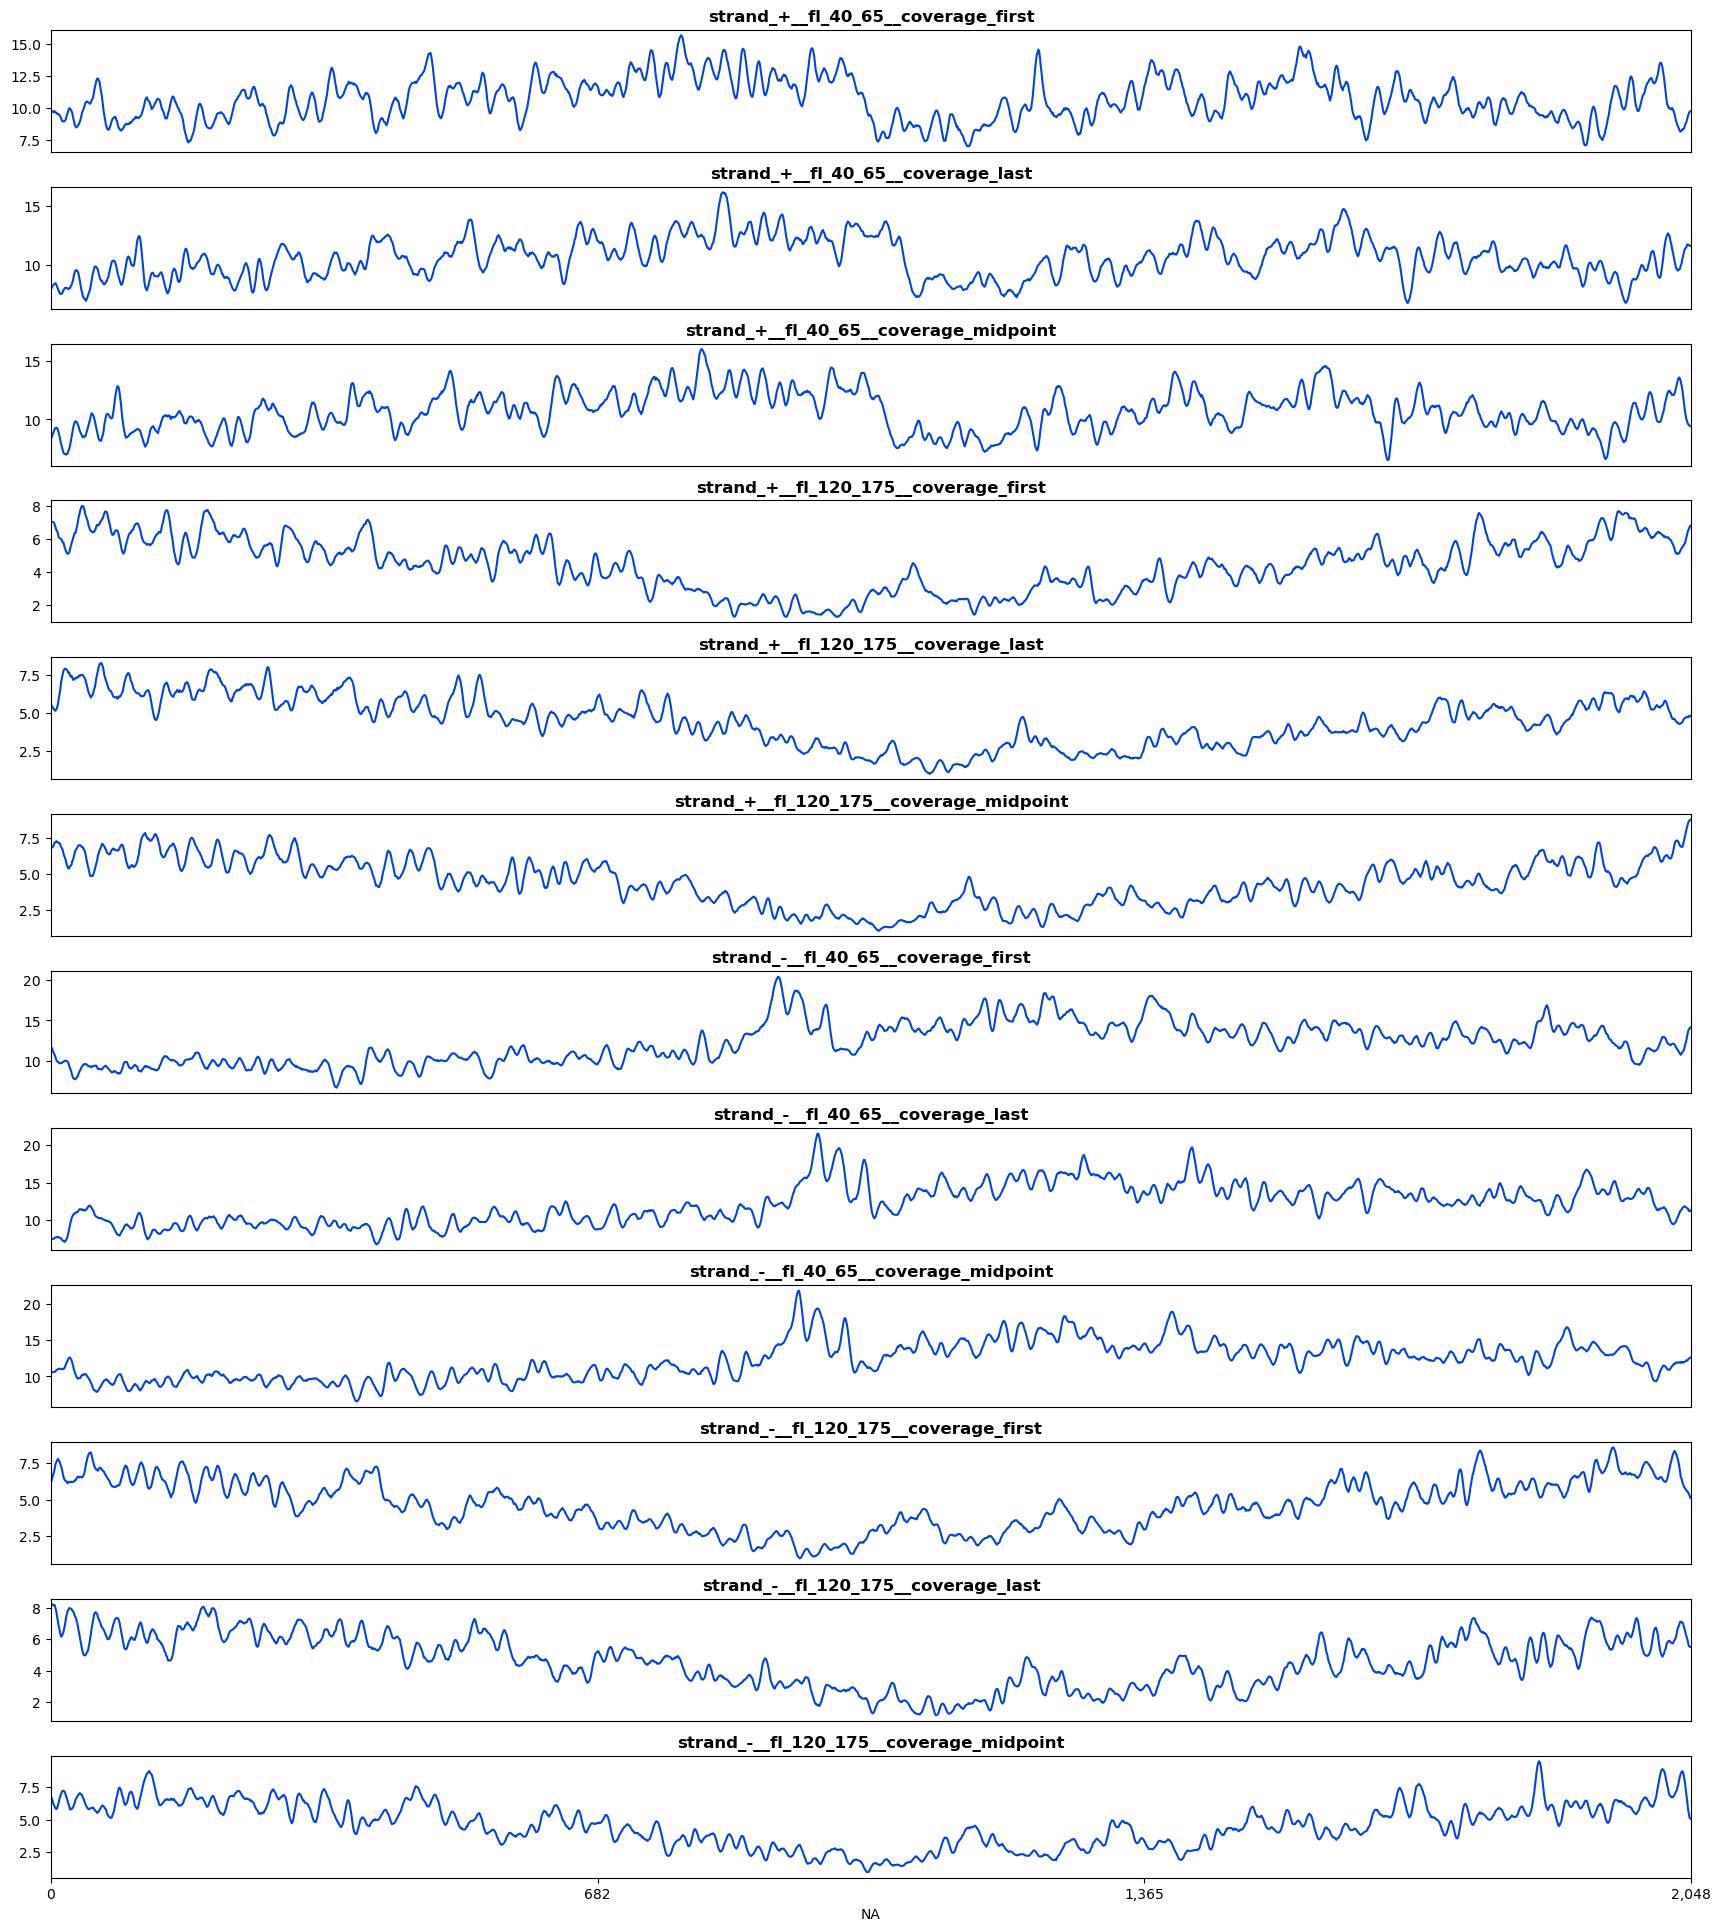

In [17]:
tracks = Tracks()
for c in cov.index:
    tracks.append(VectorTrack(cov[c], name=c, smooth=True))
tracks.plot()